In [32]:
# imports
import numpy as np
import pandas as pd

# plotting libraries
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, RandomizedSearchCV
from sklearn.model_selection import StratifiedShuffleSplit, StratifiedKFold, cross_validate

# Classifiers
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import mean_absolute_error, RocCurveDisplay, PrecisionRecallDisplay
from sklearn.metrics import classification_report, roc_auc_score, precision_recall_curve, roc_curve, auc

import xgboost as xgb


# Pipeline
from sklearn.compose import ColumnTransformer 
from sklearn.preprocessing import RobustScaler


from sklearn.feature_selection import mutual_info_classif


In [29]:
df_train = pd.read_csv('..\\data\\train.csv')
y = df_train['IsFraud']
X = df_train.drop(['IsFraud', 'Time', 'id'], axis=1)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state=42)

model = xgb.XGBClassifier()

preprocessor = ColumnTransformer([
    ("robust_scale", RobustScaler(), ['Transaction_Amount']),
], remainder='passthrough')

pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', model)
])

pipeline.fit(X_train,y_train)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('robust_scale', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [33]:
preds = model.predict(X_test)

## Use right metrics for imbalanced classification


In [34]:
# Detaiiled precision/recall/F1 by class:
print(classification_report(y_test, preds))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     29947
           1       0.00      0.00      0.00        53

    accuracy                           1.00     30000
   macro avg       0.50      0.50      0.50     30000
weighted avg       1.00      1.00      1.00     30000



c:\Users\tinew\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\tinew\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\tinew\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

In [35]:
# 2) ROC AUC for overall separability
probs = model.predict_proba(X_test)[:,1]
print('ROC AUC:', roc_auc_score(y_test, probs))

ROC AUC: 0.4520284578226565


In [36]:
# 3) Precision-Recall AUC (more informative when positives are rare):
precision, recall, _ = precision_recall_curve(y_test, probs)
print('PR AUC', auc(recall, precision))

PR AUC 0.0026248417823196146


<function matplotlib.pyplot.show(close=None, block=None)>

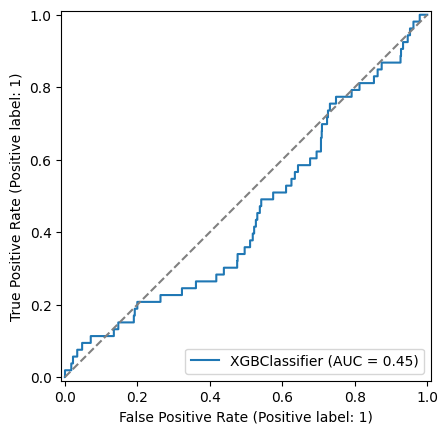

In [37]:
disp = RocCurveDisplay.from_estimator(
    model, X_test, y_test,
    # name=f'ROC (AUC = {roc_auc:.3f})'
)
plt.plot([0,1],[0,1],'--',color='gray')
plt.show

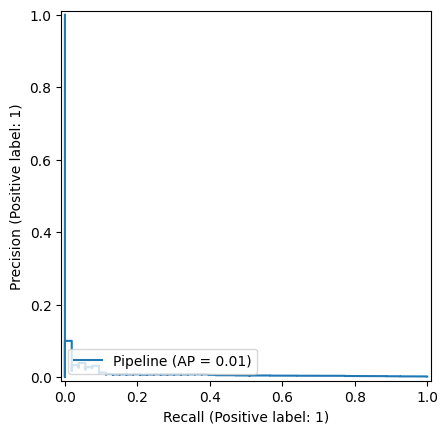

In [ ]:
disp2 = PrecisionRecallDisplay.from_estimator(
    model, X_test, y_test,
)
plt.show()

### Submission

# Submission for Kaggle

We use our model to make predictions based on the test data from the Kaggle competition Credit Card Fraud Detection (the link: https://www.kaggle.com/competitions/credit-card-fraud-prediction/)


In [ ]:
test_df = pd.read_csv('../data/test.csv')
submission_data = test_df.drop(['id','Time'], axis=1)
preds_for_submission = model.predict_proba(submission_data) # Get predictions

output = pd.DataFrame(
    {
        'id' : test_df.id,
        'IsFraud' : preds_for_submission[:,1]
    }
)
output.to_csv('submission.csv', index=False)
output.head()

c:\Users\tinew\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


,id,IsFraud
0,150000,0.39
1,150001,0.43
2,150002,0.62
3,150003,0.41
4,150004,0.60


Firstly, we got 0.68747 for the Private Score and 0.77137 for the Public Score.

Then, we dropped Time feature and got improved results: 0.70195 Private Score and 0.77137 for the Public Score.

![image.png](attachment:image.png)
